# Klasični modeli za prepoznavanje emocija iz teksta

Ova Jupyter sveska predstavlja detaljan pregled klasičnih modela.

Cilj je klasifikacija tekstova u šest emocija:

- `joy`
- `sadness`
- `anger`
- `fear`
- `love`
- `surprise`

U klasičnom delu projekta korišćeni su:

- Logistic Regression
- Multinomial Naive Bayes
- Linear SVM
- Random Forest

Tekstovi su predstavljeni pomoću **TF-IDF** reprezentacije.

## 1. Učitavanje biblioteka

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display, Image

## 2. Kratak pregled podataka

Pre modelovanja su provereni nedostajući podaci, duplikati i preklapanja između trening, validacionog i test skupa.

Nakon čišćenja korišćeni su:

- trening skup: 15 983 primera
- validacioni skup: 1 997 primera
- test skup: 2 000 primera

Test skup je čuvan odvojeno i korišćen tek za konačnu evaluaciju izabranog modela.

In [2]:
train = pd.read_csv("../data/processed/train.txt", sep=";", header=None, names=["text", "emotion"])
val = pd.read_csv("../data/processed/val.txt", sep=";", header=None, names=["text", "emotion"])
test = pd.read_csv("../data/processed/test.txt", sep=";", header=None, names=["text", "emotion"])

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

Train: (15983, 2)
Validation: (1997, 2)
Test: (2000, 2)


### Raspodela emocija

Klase nisu potpuno izbalansirane, pa je pored Accuracy korišćen i **Macro F1**, koji svim klasama daje jednaku važnost.

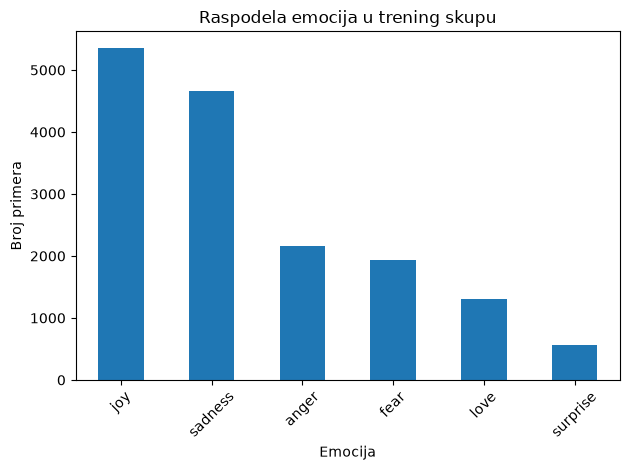

In [3]:
train["emotion"].value_counts().plot(kind="bar")
plt.xlabel("Emocija")
plt.ylabel("Broj primera")
plt.title("Raspodela emocija u trening skupu")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. TF-IDF reprezentacija

Klasični modeli ne mogu direktno da rade sa sirovim tekstom, pa je svaki tekst pretvoren u numerički vektor pomoću `TfidfVectorizer`.

TF-IDF daje veću težinu rečima koje su važne za konkretan dokument, a manju veoma čestim rečima koje se pojavljuju u velikom broju dokumenata.

### Rezultati osnovnih modela

In [4]:
baseline_results = pd.read_csv("../results/comparable_results/baseline_results.csv")
display(baseline_results)

,model,accuracy,macro_f1
0,Logistic Regression,0.8603,0.8109
1,Naive Bayes,0.6415,0.3548
2,Linear SVM,0.9009,0.8734
3,Random Forest,0.8753,0.8499


Linear SVM je ostvario najbolji rezultat među osnovnim modelima, sa Accuracy oko 0.901 i Macro F1 oko 0.873. Mala razlika između ove dve metrike pokazuje da model ne radi dobro samo na najzastupljenijim klasama, već relativno ujednačeno klasifikuje i ređe emocije.

Random Forest je takođe ostvario dobar rezultat, sa Macro F1 oko 0.850, ali je ipak bio slabiji od SVM-a.

Logistic Regression ima Accuracy oko 0.860, ali niži Macro F1 od 0.811. To znači da je ukupno dosta predikcija tačno, ali performanse nisu jednako dobre za sve klase.

Najveća razlika između Accuracy i Macro F1 javlja se kod Naive Bayes modela: Accuracy je oko 0.642, dok je Macro F1 samo 0.355. To pokazuje da model mnogo bolje prepoznaje češće klase, dok veoma loše radi na ređim emocijama. Zbog nebalansiranosti skupa, upravo zato nam je Macro F1 važniji za poređenje modela od samog Accuracy-ja.

## 5. Podešavanje hiperparametara

Za najperspektivnije modele, Linear SVM i Logistic Regression, korišćen je `GridSearchCV`.

GridSearchCV je radio samo na trening skupu i koristio 3-fold unakrsnu validaciju.

Podešavani su:

- `ngram_range`
- `C`
- `class_weight`

Kod TF-IDF-a:

- `(1, 1)` koristi samo pojedinačne reči
- `(1, 2)` koristi pojedinačne reči i parove susednih reči

`class_weight="balanced"` daje veću težinu ređim klasama.

In [5]:
tuned_results = pd.read_csv("../results/comparable_results/tuned_results.csv")
display(tuned_results)

,model,accuracy,macro_f1
0,Linear SVM tuned,0.901853,0.879462
1,Logistic Regression tuned,0.894842,0.870970


### Uticaj podešavanja hiperparametara

Kod SVM-a podešavanje je povećalo Macro F1 sa približno 0.873 na 0.879, dok se Accuracy promenio veoma malo. To znači da podešavanje nije samo povećalo ukupan broj tačnih predikcija, već je pre svega malo poboljšalo ravnotežu performansi između različitih emocija.

Kod logističke regresije poboljšanje je izraženije: Macro F1 je porastao sa približno 0.811 na 0.871, a Accuracy sa 0.860 na 0.895. Posebno je značajno što je najbolja konfiguracija koristila class_weight="balanced", što je pomoglo modelu da pridaje veću važnost ređim klasama.

### Najbolji parametri SVM modela

- `C = 0.5`
- `class_weight = "balanced"`
- `ngram_range = (1, 1)`

Podešeni Linear SVM imao je najbolji Macro F1 na validacionom skupu i zato je izabran kao konačni klasični model.

## 6. Matrice konfuzije

Matrice konfuzije pokazuju koje klase model najčešće meša.

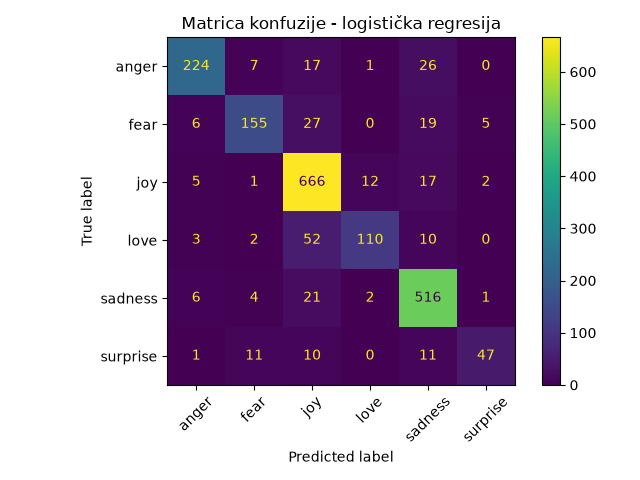

In [6]:
display(Image(filename="../results/logistic_regression/confusion_matrix_logistic_regression.png"))

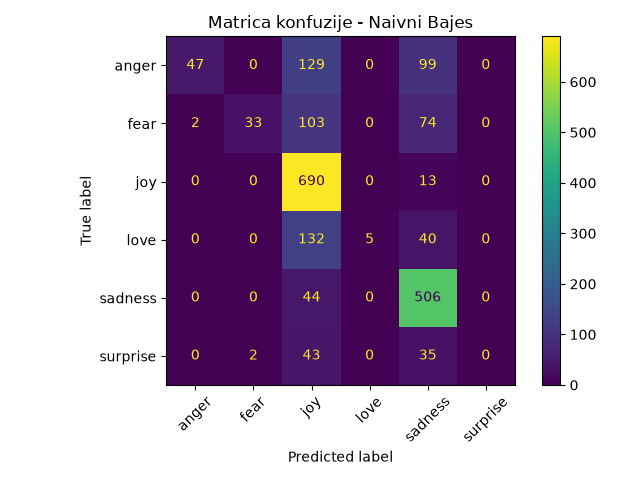

In [7]:
display(Image(filename="../results/naive_bayes/confusion_matrix_naive_bayes.png"))

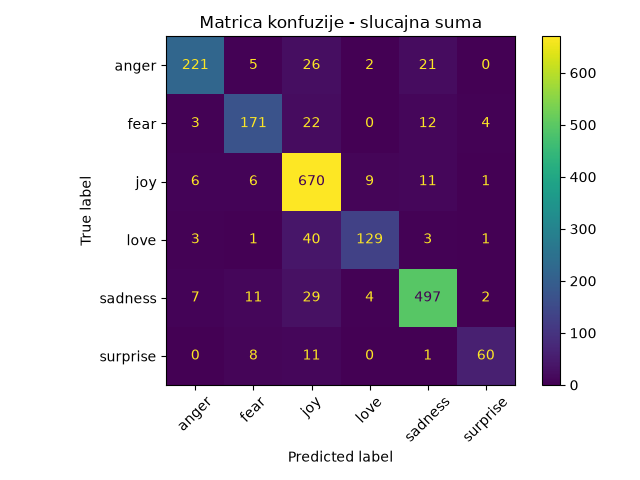

In [8]:
display(Image(filename="../results/random_forest/confusion_matrix_random_forest.png"))

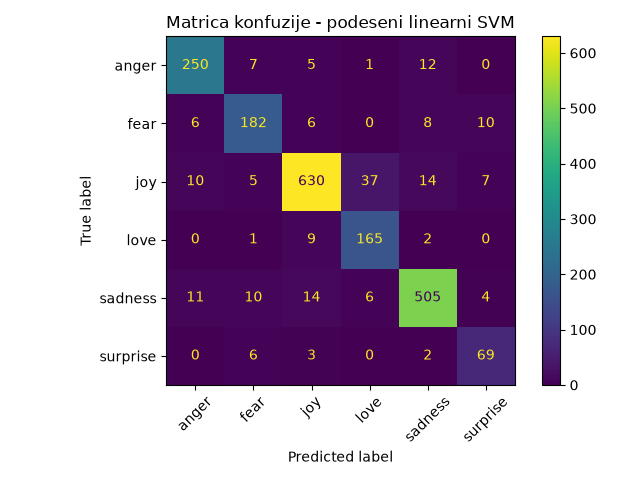

In [9]:
display(Image(filename="../results/SVM/confusion_matrix_svm_tuned.png"))

## 7. Konačni klasični model

Nakon izbora modela i hiperparametara, trening i validacioni skup su spojeni.

Konačni SVM je obučen na skupu `train + validation`, dok je test skup korišćen samo jednom za završnu evaluaciju.

In [10]:
all_results = pd.read_csv("../results/comparable_results/final_results.csv")
final_svm_result = all_results[all_results["model"] == "Linear SVM"]
display(final_svm_result)

,model,accuracy,macro_f1
0,Linear SVM,0.897,0.8536


Konačni rezultat Linear SVM modela na test skupu:

- Accuracy ≈ **0.897**
- Macro F1 ≈ **0.854**

### Matrica konfuzije konačnog SVM modela

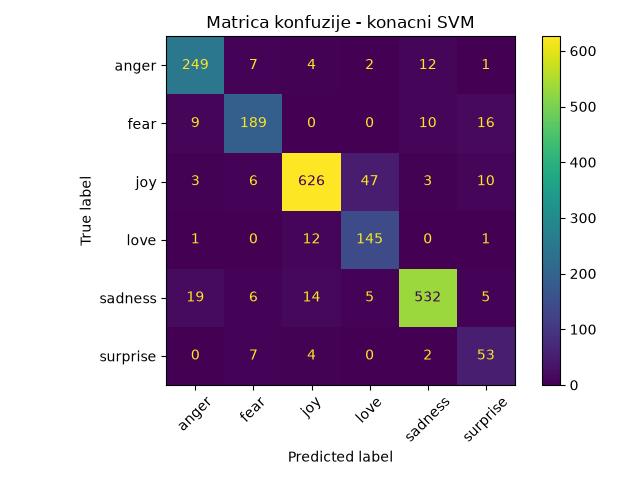

In [11]:
display(Image(filename="../results/SVM/confusion_matrix_final_svm.png"))

## 8. Učitavanje sačuvanog modela

Finalni model je sačuvan kao ceo `Pipeline`, pa se zajedno učitavaju:

- TF-IDF vektorizator
- Linear SVM


In [14]:
model = joblib.load("../models/classical_ml/final_svm.joblib")
print("Finalni SVM model je učitan.")

Finalni SVM model je učitan.


## 9. Primeri predikcija

In [15]:
primeri = [
    "i feel very happy today",
    "i am scared about what will happen",
    "i feel deeply sad and lonely",
    "i am so angry right now",
    "i feel loved and appreciated",
    "i am completely surprised by this"
]

predikcije = model.predict(primeri)

for tekst, emocija in zip(primeri, predikcije):
    print(tekst, "->", emocija)

i feel very happy today -> joy
i am scared about what will happen -> fear
i feel deeply sad and lonely -> sadness
i am so angry right now -> anger
i feel loved and appreciated -> love
i am completely surprised by this -> surprise


## 10. Poređenje klasičnih modela

Na sledećem grafikonu porede se osnovni klasični modeli prema Accuracy i Macro F1 metrici.

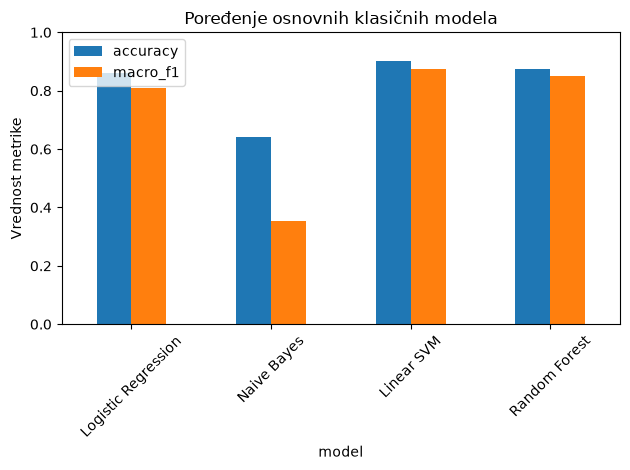

In [16]:
baseline_results.set_index("model")[["accuracy", "macro_f1"]].plot(kind="bar")
plt.ylabel("Vrednost metrike")
plt.title("Poređenje osnovnih klasičnih modela")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Zaključak

Od četiri isprobana klasična modela najbolji rezultat ostvario je **Linear SVM**.

Podešavanje hiperparametara pomoću `GridSearchCV` dodatno je poboljšalo rezultat SVM modela.

Konačni podešeni Linear SVM je na test skupu ostvario:

- Accuracy ≈ **0.897**
- Macro F1 ≈ **0.854**

Rezultati pokazuju da TF-IDF u kombinaciji sa linearnim SVM modelom predstavlja jak klasični pristup za ovaj problem klasifikacije emocija.